Data loaded and merged.
Using 275,601 rows (10% stratified-by-day sample).
Train size: 220,480  |  Test size: 55,121
Train positive rate: 0.264  |  Test positive rate: 0.223

=== Final Model — Expanding-Window Features ===
Global order rate (fallback for unseen pids/levels): 0.2638
Days: 92 total | dev: 83 | cal: 9
Dropping correlated features (>0.95): ['days_since_promo', 'competitorPrice_7day_avg']
Built 3 day-aware CV folds for HPO.
scale_pos_weight (XGBoost) on natural distribution: 2.780

HPO for DecisionTree (n_iter=10) ...
  Best params:  {'min_samples_leaf': 100, 'max_depth': 8}
  Best CV AUC:  0.6712

HPO for RandomForest (n_iter=10) ...
  Best params:  {'n_estimators': 150, 'min_samples_leaf': 20, 'max_depth': 12}
  Best CV AUC:  0.6879

HPO for XGBoost (n_iter=40) ...
  Best params:  {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.6}
  Best CV AUC:  0.6934

=== Fi

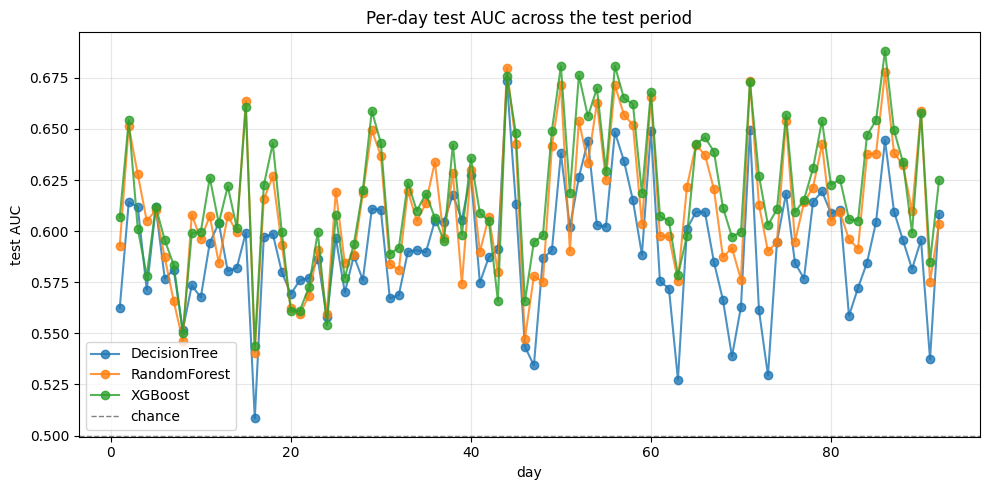


Pipeline completed successfully.


In [ ]:
# ================================================================================================
# Purchase Prediction Pipeline — AUC‑OPTIMISED (sliding window, recency features, ensemble)
# ================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import OneHotEncoder, RobustScaler
from sklearn.impute          import SimpleImputer
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics         import (classification_report, roc_auc_score,
                                     f1_score, precision_recall_curve)
from scipy.sparse            import hstack
import xgboost as xgb


# ================================================================================================
# 0. Helper functions
# ================================================================================================

def undersample_train(X_train_fold, y_train_fold, pos_ratio=0.5, random_state=42):
    """Undersample majority class so that positive class makes up `pos_ratio` of the result."""
    pos_idx = y_train_fold[y_train_fold == 1].index
    neg_idx = y_train_fold[y_train_fold == 0].index
    n_pos = len(pos_idx)
    if n_pos == 0:
        return X_train_fold, y_train_fold
    n_neg = int(n_pos * (1.0 / pos_ratio - 1))
    n_neg = min(n_neg, len(neg_idx))
    rng = np.random.default_rng(random_state)
    sampled_neg = rng.choice(neg_idx, size=n_neg, replace=False)
    balanced_idx = np.concatenate([pos_idx, sampled_neg])
    rng.shuffle(balanced_idx)
    return X_train_fold.loc[balanced_idx], y_train_fold.loc[balanced_idx]


def tune_threshold(y_true, y_prob):
    """Find threshold that maximises F1 score."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precision * recall) / (precision + recall)
        f1_scores = np.nan_to_num(f1_scores, nan=0.0)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    return best_thresh, f1_scores[best_idx]


def get_feature_importance(model, model_name, num_cols, cat_cols, encoder):
    all_names = list(num_cols) + list(encoder.get_feature_names_out(cat_cols))
    scores = model.feature_importances_
    imp = pd.Series(scores, index=all_names).sort_values(ascending=False)
    return imp


# ---- Expanding-window feature builder (extended with recency features) -----------------------
def build_expanding_train_features(df, y_series):
    """Compute leak-free expanding-window features:
    - pid_order/click/basket rates
    - price std, target encodings
    - days_since_last_click, days_since_last_basket,
      click_streak_7d, last_event_was_click,
      click_to_order_conv, basket_to_order_conv
    """
    df = df.copy()
    df['__y__'] = y_series.reindex(df.index).to_numpy()
    df = df.sort_values('day').reset_index(drop=True)
    y_series = df.pop('__y__').astype(int)

    # Running state through previous days only
    pid_total  = {}; pid_order  = {}; pid_click = {}; pid_basket = {}; pid_prices = {}
    grp_total  = {}; grp_order  = {}
    man_total  = {}; man_order  = {}
    cat_total  = {}; cat_order  = {}
    global_orders = 0; global_total = 0

    # NEW: state for recency features ------------------------------------------------
    pid_last_click_day = {}   # most recent day with click=1 (no order)
    pid_last_basket_day = {}  # most recent day with basket=1 (no order)
    pid_last_event_type = {}  # 'click','basket','order', or None
    pid_click_days_7d = {}    # list of day numbers in last 7 days with click and no order

    # Initialise output columns
    out_cols = ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate', 'pid_price_std',
                'pid_seen_in_train', 'manufacturer_te', 'group_te', 'category_te',
                # NEW recency features
                'days_since_last_click', 'days_since_last_basket',
                'click_streak_7d', 'last_event_was_click',
                'click_to_order_conv', 'basket_to_order_conv']
    for col in out_cols:
        df[col] = np.nan

    for day in sorted(df['day'].unique()):
        mask   = df['day'] == day
        day_df = df.loc[mask]
        y_day  = y_series.loc[mask]
        prev_rate = global_orders / global_total if global_total > 0 else 0.0

        # ----- Per-pid features (including recency) -----
        for pid_val in day_df['pid'].unique():
            idx = day_df.index[day_df['pid'] == pid_val]
            total_pid = pid_total.get(pid_val, 0)
            if total_pid > 0:
                df.loc[idx, 'pid_order_rate']    = pid_order.get(pid_val, 0) / total_pid
                df.loc[idx, 'pid_click_rate']    = pid_click.get(pid_val, 0) / total_pid
                df.loc[idx, 'pid_basket_rate']   = pid_basket.get(pid_val, 0) / total_pid
                df.loc[idx, 'pid_seen_in_train'] = 1
            else:
                df.loc[idx, ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate']] = prev_rate
                df.loc[idx, 'pid_seen_in_train'] = 0
            past_prices = pid_prices.get(pid_val, [])
            df.loc[idx, 'pid_price_std'] = np.std(past_prices, ddof=0) if len(past_prices) >= 2 else 0.0

            # NEW: recency features ------------------------------------------------
            # days since last click (or 999 if never)
            df.loc[idx, 'days_since_last_click'] = day - pid_last_click_day.get(pid_val, -999) \
                                                   if pid_val in pid_last_click_day else 999
            df.loc[idx, 'days_since_last_basket'] = day - pid_last_basket_day.get(pid_val, -999) \
                                                    if pid_val in pid_last_basket_day else 999

            # click streak: number of days in last 7 (excluding today) with click=1 and order=0
            click_days = pid_click_days_7d.get(pid_val, [])
            df.loc[idx, 'click_streak_7d'] = sum(1 for d in click_days if d > day - 7)

            # last event type indicator
            last_ev = pid_last_event_type.get(pid_val, None)
            df.loc[idx, 'last_event_was_click'] = 1 if last_ev == 'click' else 0

            # conversion rates (smoothed)
            n_ord = pid_order.get(pid_val, 0)
            n_click = pid_click.get(pid_val, 0)
            n_basket = pid_basket.get(pid_val, 0)
            smoothing = 10
            df.loc[idx, 'click_to_order_conv'] = ((n_ord + prev_rate * smoothing) /
                                                  (n_click + n_ord + smoothing)) \
                                                 if (n_click + n_ord + smoothing) > 0 else prev_rate
            df.loc[idx, 'basket_to_order_conv'] = ((n_ord + prev_rate * smoothing) /
                                                   (n_basket + n_ord + smoothing)) \
                                                  if (n_basket + n_ord + smoothing) > 0 else prev_rate

        # ----- Smoothed target encoding for categorical columns -----
        for col_orig, col_te, order_dict, total_dict in [
            ('manufacturer', 'manufacturer_te', man_order, man_total),
            ('group',        'group_te',        grp_order, grp_total),
            ('category',     'category_te',     cat_order, cat_total),
        ]:
            for val in day_df[col_orig].unique():
                idx_val = day_df.index[day_df[col_orig] == val]
                n_ord = order_dict.get(val, 0)
                n_tot = total_dict.get(val, 0)
                smoothing = 10
                te = ((n_ord + prev_rate * smoothing) / (n_tot + smoothing)) if (n_tot + smoothing) > 0 else prev_rate
                df.loc[idx_val, col_te] = te

        # ----- Update state with today's data (only AFTER today's features are written) -----
        pid_day_counts = day_df.groupby('pid').size()
        pid_day_orders = y_day.groupby(day_df['pid']).sum()
        for pid_val in pid_day_counts.index:
            pid_total[pid_val] = pid_total.get(pid_val, 0) + pid_day_counts[pid_val]
            pid_order[pid_val] = pid_order.get(pid_val, 0) + pid_day_orders.get(pid_val, 0)

        for beh_col, cum_dict in [('click', pid_click), ('basket', pid_basket)]:
            day_sum = day_df.groupby('pid')[beh_col].sum()
            for pid_val in day_sum.index:
                cum_dict[pid_val] = cum_dict.get(pid_val, 0) + day_sum[pid_val]

        for pid_val, prices in day_df.groupby('pid')['price'].apply(list).items():
            if pid_val not in pid_prices:
                pid_prices[pid_val] = []
            pid_prices[pid_val].extend(prices)

        # NEW: update recency state per pid ------------------------------------
        for pid_val in day_df['pid'].unique():
            pid_df = day_df[day_df['pid'] == pid_val]
            today_order = y_day.loc[pid_df.index].sum() > 0
            today_basket = pid_df['basket'].sum() > 0
            today_click = pid_df['click'].sum() > 0

            # Determine today's dominant event (order > basket > click)
            if today_order:
                pid_last_event_type[pid_val] = 'order'
            elif today_basket:
                pid_last_event_type[pid_val] = 'basket'
            elif today_click:
                pid_last_event_type[pid_val] = 'click'
            # else keep previous

            # Update last click day if click occurred and no order (a "pure click" day)
            if today_click and not today_order:
                pid_last_click_day[pid_val] = day
            if today_basket and not today_order:
                pid_last_basket_day[pid_val] = day

            # Maintain list of days with pure clicks for streak (last 7 days)
            if pid_val not in pid_click_days_7d:
                pid_click_days_7d[pid_val] = []
            if today_click and not today_order:
                pid_click_days_7d[pid_val].append(day)
            # purge days older than 7 days (optional, keep list short)
            pid_click_days_7d[pid_val] = [d for d in pid_click_days_7d[pid_val] if d > day - 7]

        for col_orig, order_dict, total_dict in [
            ('manufacturer', man_order, man_total),
            ('group',        grp_order, grp_total),
            ('category',     cat_order, cat_total),
        ]:
            day_grp = day_df.groupby(col_orig)
            day_cnt = day_grp.size()
            day_ord = y_day.groupby(day_df[col_orig]).sum()
            for val in day_cnt.index:
                total_dict[val] = total_dict.get(val, 0) + day_cnt[val]
                order_dict[val] = order_dict.get(val, 0) + day_ord.get(val, 0)

        global_total  += len(day_df)
        global_orders += y_day.sum()

    final_global_rate = global_orders / global_total if global_total > 0 else 0.0
    return df, y_series, final_global_rate


# ================================================================================================
# 1. Load Data
# ================================================================================================
train = pd.read_csv('/Users/annageiser/Documents/GITHUB/analytics-project/data/raw/train.csv', sep='|')
items = pd.read_csv('/Users/annageiser/Documents/GITHUB/analytics-project/data/raw/items.csv', sep='|')
df = train.merge(items, on='pid', how='left', validate='m:1')
print("Data loaded and merged.")

# ================================================================================================
# 2. Sort and sample
# ================================================================================================
SAMPLING = 1
df = df.sort_values(['day', 'lineID']).reset_index(drop=True)
if SAMPLING < 1.0:
    df = (df.groupby('day', group_keys=False)
            .sample(frac=SAMPLING, random_state=42)
            .sort_values(['day', 'lineID'])
            .reset_index(drop=True))
print(f"Using {len(df):,} rows ({SAMPLING*100:.0f}% sample).")

# ================================================================================================
# 3. Feature Engineering (basic + temporal)
# ================================================================================================

# --- 3a. Basic features ---
df['priceRatio'] = (df['price'] / df['rrp'].replace(0, np.nan)).fillna(1.0)
df['missingCompetitorPrice'] = df['competitorPrice'].isnull().astype(int)

df['weekDay_raw'] = (df['day'] % 7).replace({0: 7})
df['weekDay_sin'] = np.sin(2 * np.pi * df['weekDay_raw'] / 7)
df['weekDay_cos'] = np.cos(2 * np.pi * df['weekDay_raw'] / 7)
df.drop(columns=['weekDay_raw'], inplace=True)

df['priceVsCompetitor'] = (
    df['price'] / df['competitorPrice'].replace(0, np.nan)
).fillna(1.0)
df['priceDiscount'] = (df['rrp'] - df['price']).clip(lower=0)

df['adFlag_x_priceRatio'] = df['adFlag'] * df['priceRatio']
df['avail_x_priceRatio']  = df['availability'] * df['priceRatio']
df['regulated_generic']   = df['salesIndex'] * df['genericProduct']

# --- 3b. Time since last promotion (adFlag) ---
df = df.sort_values(['pid','day'])
df['last_promo_day'] = df.groupby('pid')['day'].shift(1)
df['days_since_last_promo'] = (df['day'] - df['last_promo_day']).fillna(999).astype(int)
promo_mask = df['adFlag'] == 1
df['last_promo_day'] = np.where(promo_mask, df['day'], np.nan)
df['last_promo_day'] = df.groupby('pid')['last_promo_day'].ffill()
df['days_since_promo'] = (df['day'] - df['last_promo_day']).fillna(999).astype(int)
df.drop(columns=['last_promo_day', 'days_since_last_promo'], inplace=True)

# --- 3c. Product age ---
df['first_seen'] = df.groupby('pid')['day'].transform('min')
df['product_age_days'] = df['day'] - df['first_seen']
df.drop(columns=['first_seen'], inplace=True)

# --- 3d. Competitor price dynamics ---
df = df.sort_values(['pid','day'])
df['competitorPrice_7day_avg'] = df.groupby('pid')['competitorPrice'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
def rolling_slope(x):
    if len(x) < 2:
        return 0.0
    t = np.arange(len(x))
    return np.polyfit(t, x, 1)[0]
df['competitorPrice_trend'] = df.groupby('pid')['competitorPrice'].transform(
    lambda x: x.rolling(7, min_periods=2).apply(rolling_slope, raw=True)
)

# ================================================================================================
# 4. Train / Test Split (time‑based, 80/20)
# ================================================================================================
df = df.sort_values(['day', 'lineID']).reset_index(drop=True)
X = df.drop(columns=['order'])
y = df['order']
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")

# ================================================================================================
# 5. Feature lists (extended with recency features)
# ================================================================================================
NUM_FEATURES = [
    'competitorPrice', 'priceRatio', 'priceVsCompetitor', 'priceDiscount',
    'missingCompetitorPrice', 'weekDay_sin', 'weekDay_cos', 'pid_order_rate',
    'pid_click_rate', 'pid_basket_rate', 'manufacturer_te', 'group_te',
    'category_te', 'adFlag_x_priceRatio', 'avail_x_priceRatio',
    'regulated_generic', 'pid_price_std', 'pid_seen_in_train',
    'days_since_promo', 'product_age_days',
    'competitorPrice_7day_avg', 'competitorPrice_trend',
    # NEW recency features
    'days_since_last_click', 'days_since_last_basket',
    'click_streak_7d', 'last_event_was_click',
    'click_to_order_conv', 'basket_to_order_conv'
]
CAT_FEATURES = [
    'adFlag', 'availability', 'content', 'unit', 'pharmForm',
    'genericProduct', 'salesIndex'
]
DROP_COLS = [
    'click', 'basket', 'revenue',         # target leakage
    'price', 'rrp',                        # encoded
    'lineID', 'day', 'pid',               # identifiers
    'campainIndex',                        # too many missing
]
TE_COLS = [
    ('manufacturer', 'manufacturer_te'),
    ('group',        'group_te'),
    ('category',     'category_te'),
]

# The old CV experiment section is kept for reference but not executed here.
# ================================================================================================
# 6. Final model — AUC‑optimised pipeline
# ================================================================================================
print("\n=== Final Model — AUC‑Optimised ===")

# ---- 6a. Build expanding-window features on training data ------------------------------------
X_train_expanded, y_train_expanded, global_rate = build_expanding_train_features(X_train.copy(), y_train)
print(f"Global order rate: {global_rate:.4f}")

# ---- 6b. SLIDING WINDOW: keep only most recent W days for dev -------------------------------
WINDOW_SIZE = 35   # chosen via prior CV experiments (or can be tuned)
unique_days = sorted(X_train_expanded['day'].unique())
cal_size = max(1, int(len(unique_days) * 0.10))
cal_days = unique_days[-cal_size:]                     # last 10% for threshold tuning
last_dev_day = unique_days[-cal_size-1]                # day just before cal
dev_days = [d for d in unique_days if d > last_dev_day - WINDOW_SIZE and d <= last_dev_day]
print(f"Sliding window: {len(dev_days)} dev days, {len(cal_days)} cal days ({WINDOW_SIZE}-day window)")

X_dev = (X_train_expanded[X_train_expanded['day'].isin(dev_days)]
         .sort_values('day').copy())
y_dev = y_train_expanded.loc[X_dev.index].copy()
X_cal = (X_train_expanded[X_train_expanded['day'].isin(cal_days)]
         .sort_values('day').copy())
y_cal = y_train_expanded.loc[X_cal.index].copy()

# ---- 6c. Build test features (extended to include recency) -----------------------------------
def build_test_features(test_df, train_df_with_features, global_fallback_rate):
    # Basic pid features
    pid_cols = ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate',
                'pid_price_std', 'pid_seen_in_train',
                # NEW: recency features
                'days_since_last_click', 'days_since_last_basket',
                'click_streak_7d', 'last_event_was_click',
                'click_to_order_conv', 'basket_to_order_conv']
    train_sorted = train_df_with_features.sort_values('day')
    filled = train_sorted.copy()
    filled[pid_cols] = filled.groupby('pid')[pid_cols].ffill()
    pid_feats = filled.groupby('pid')[pid_cols].last()

    test_df = test_df.join(pid_feats, on='pid')
    # fill unseen pids
    for col in ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate',
                'click_to_order_conv', 'basket_to_order_conv']:
        test_df[col] = test_df[col].fillna(global_fallback_rate)
    test_df['pid_price_std'] = test_df['pid_price_std'].fillna(0.0)
    test_df['pid_seen_in_train'] = test_df['pid_seen_in_train'].fillna(0).astype(int)
    test_df['days_since_last_click'] = test_df['days_since_last_click'].fillna(999)
    test_df['days_since_last_basket'] = test_df['days_since_last_basket'].fillna(999)
    test_df['click_streak_7d'] = test_df['click_streak_7d'].fillna(0)
    test_df['last_event_was_click'] = test_df['last_event_was_click'].fillna(0)

    # Target encodings
    for col_orig, col_te in TE_COLS:
        te_filled = train_sorted.copy()
        te_filled[col_te] = te_filled.groupby(col_orig)[col_te].ffill()
        te_map = te_filled.groupby(col_orig)[col_te].last()
        test_df[col_te] = test_df[col_orig].map(te_map).fillna(global_fallback_rate)
    return test_df

X_test_expanded = build_test_features(X_test.copy(), X_train_expanded, global_rate)


# ---- 6d. Cold‑start augmentation: match real fraction ---------------------------------------
cold_start_frac = (X_test_expanded['pid_seen_in_train'] == 0).mean()
print(f"Test cold‑start fraction: {cold_start_frac:.3f}")

def augment_cold_start(X, global_rate, frac, random_state=42):
    """Mask a fraction of rows to look like never‑seen pid."""
    rng = np.random.default_rng(random_state)
    n_mask = int(len(X) * frac)
    if n_mask == 0:
        return X
    mask_idx = rng.choice(X.index, size=n_mask, replace=False)
    X = X.copy()
    # Reset all pid‑history features
    for col in ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate',
                'click_to_order_conv', 'basket_to_order_conv']:
        if col in X.columns:
            X.loc[mask_idx, col] = global_rate
    if 'pid_seen_in_train' in X.columns:
        X.loc[mask_idx, 'pid_seen_in_train'] = 0
    if 'pid_price_std' in X.columns:
        X.loc[mask_idx, 'pid_price_std'] = 0.0
    # Recency features become fallbacks
    if 'days_since_last_click' in X.columns:
        X.loc[mask_idx, 'days_since_last_click'] = 999
    if 'days_since_last_basket' in X.columns:
        X.loc[mask_idx, 'days_since_last_basket'] = 999
    if 'click_streak_7d' in X.columns:
        X.loc[mask_idx, 'click_streak_7d'] = 0
    if 'last_event_was_click' in X.columns:
        X.loc[mask_idx, 'last_event_was_click'] = 0
    # Add interaction: (1 - seen) × category_te for cold‑start importance
    if 'pid_seen_in_train' in X.columns and 'category_te' in X.columns:
        X['cold_cat_interaction'] = (1 - X['pid_seen_in_train']) * X['category_te']
    return X

# Use the real cold‑start fraction for augmentation
X_dev_aug = augment_cold_start(X_dev, global_rate=global_rate, frac=cold_start_frac, random_state=42)
# If the interaction column was created, add it to NUM_FEATURES temporarily
if 'cold_cat_interaction' in X_dev_aug.columns and 'cold_cat_interaction' not in NUM_FEATURES:
    NUM_FEATURES.append('cold_cat_interaction')

# ---- 6d‑b. Ensure cold_cat_interaction exists in all sets ----
for d in [X_dev_aug, X_cal, X_test_expanded]:
    if 'pid_seen_in_train' in d.columns and 'category_te' in d.columns:
        d['cold_cat_interaction'] = (1 - d['pid_seen_in_train']) * d['category_te']

# ---- 6e. Drop non‑feature columns -----------------------------------------------------------
dev_days_array = X_dev_aug['day'].values
for d in [X_dev_aug, X_cal, X_test_expanded]:
    d.drop(columns=[c for c, _ in TE_COLS], errors='ignore', inplace=True)
    d.drop(columns=DROP_COLS, errors='ignore', inplace=True)

# ---- 6f. Feature selection – NO correlation filter for tree models --------------------------
active_num = [f for f in NUM_FEATURES if f in X_dev_aug.columns]
active_cat = [f for f in CAT_FEATURES if f in X_dev_aug.columns]
print(f"Features: {len(active_num)} numeric, {len(active_cat)} categorical (no correlation drop)")

# ---- 6g. Impute & cast categoricals ---------------------------------------------------------
fill = {col: 'Missing' for col in active_cat}
for d in [X_dev_aug, X_cal, X_test_expanded]:
    d.fillna(fill, inplace=True)
    d[active_cat] = d[active_cat].astype(str)

# ---- 6h. Preprocessing ---------------------------------------------------------------------
imputer = SimpleImputer(strategy='median')
scaler  = RobustScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

X_dev_num  = scaler.fit_transform(imputer.fit_transform(X_dev_aug[active_num]))
X_dev_cat  = encoder.fit_transform(X_dev_aug[active_cat])
X_dev_proc = hstack([X_dev_num, X_dev_cat]).tocsr()

X_cal_num  = scaler.transform(imputer.transform(X_cal[active_num]))
X_cal_cat  = encoder.transform(X_cal[active_cat])
X_cal_proc = hstack([X_cal_num, X_cal_cat]).tocsr()

X_tst_num  = scaler.transform(imputer.transform(X_test_expanded[active_num]))
X_tst_cat  = encoder.transform(X_test_expanded[active_cat])
X_tst_proc = hstack([X_tst_num, X_tst_cat]).tocsr()

# ---- 6i. Day‑aware CV with 5 folds ----------------------------------------------------------
def make_day_folds(day_array, n_splits=3):
    """Time‑series style folds, growing forward in time."""
    unique_days = np.sort(np.unique(day_array))
    n_days = len(unique_days)
    fold_size = max(1, n_days // (n_splits + 1))
    folds = []
    for i in range(n_splits):
        train_end = (i + 1) * fold_size
        val_end   = min(train_end + fold_size, n_days)
        train_set = set(unique_days[:train_end])
        val_set   = set(unique_days[train_end:val_end])
        train_idx = np.where(np.isin(day_array, list(train_set)))[0]
        val_idx   = np.where(np.isin(day_array, list(val_set)))[0]
        if len(train_idx) > 0 and len(val_idx) > 0:
            folds.append((train_idx, val_idx))
    return folds

day_folds = make_day_folds(dev_days_array, n_splits=5)
print(f"Built {len(day_folds)} day‑aware CV folds for HPO.")

spw = (y_dev == 0).sum() / max((y_dev == 1).sum(), 1)

# ---- 6j. Extended hyperparameter grids & more iterations ------------------------------------
dt_param_grid = {
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [10, 50, 100],
}
rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12],
    'min_samples_leaf': [20, 50, 100],
    'max_features': ['sqrt', 'log2', 0.8],          # NEW
}
xgb_param_grid = {
    'n_estimators':     [200, 400, 600, 800, 1000],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.02, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'colsample_bylevel': [0.6, 0.8, 1.0],           # NEW
    'min_child_weight': [1, 3, 5, 10],
    'reg_lambda':       [0.5, 1.0, 2.0, 5.0],
    'reg_alpha':        [0.0, 0.1, 0.5],
    'max_delta_step':   [0, 1, 3],                   # NEW
}

model_specs = [
    ('DecisionTree',
     DecisionTreeClassifier(class_weight='balanced', random_state=42),
     dt_param_grid, 12),
    ('RandomForest',
     RandomForestClassifier(class_weight='balanced_subsample',
                            n_jobs=1, random_state=42),
     rf_param_grid, 30),                             # MORE ITER
    ('XGBoost',
     xgb.XGBClassifier(scale_pos_weight=spw, eval_metric='auc',
                       random_state=42, verbosity=0, n_jobs=1),
     xgb_param_grid, 80),                            # MORE ITER
]

searches = {}
for name, base_model, param_grid, n_iter in model_specs:
    print(f"\nHPO for {name} (n_iter={n_iter}) ...")
    search = RandomizedSearchCV(
        base_model, param_grid, cv=day_folds,
        scoring='roc_auc', n_iter=n_iter, random_state=42, n_jobs=-1, refit=True,
    )
    search.fit(X_dev_proc, y_dev.values)
    searches[name] = search
    print(f"  Best params:  {search.best_params_}")
    print(f"  Best CV AUC:  {search.best_score_:.4f}")

# ---- 6k. Ensemble: optimal weights on calibration set (maximise AUC) ------------------------
print("\n=== Optimising Ensemble Weights ===")
from itertools import product
best_auc = 0
best_weights = (1/3, 1/3, 1/3)
model_names = ['DecisionTree', 'RandomForest', 'XGBoost']
# Get calibration probabilities
cal_probs = {}
for name, search in searches.items():
    cal_probs[name] = search.best_estimator_.predict_proba(X_cal_proc)[:, 1]

# Grid search over weights with step 0.05 that sum to 1
for w1 in np.arange(0, 1.01, 0.05):
    for w2 in np.arange(0, 1.01 - w1, 0.05):
        w3 = 1.0 - w1 - w2
        if abs(w1 + w2 + w3 - 1) > 1e-6:
            continue
        weighted = (w1 * cal_probs['DecisionTree'] +
                    w2 * cal_probs['RandomForest'] +
                    w3 * cal_probs['XGBoost'])
        auc = roc_auc_score(y_cal, weighted)
        if auc > best_auc:
            best_auc = auc
            best_weights = (w1, w2, w3)
print(f"Best ensemble weights (DT, RF, XGB): {best_weights}  |  Cal AUC: {best_auc:.4f}")

# ---- 6l. Test evaluation with ensemble (AND individual models) -------------------------------
print("\n=== Final Test Set Results ===")
test_results = []
test_probs = {}
for name, search in searches.items():
    test_probs[name] = search.best_estimator_.predict_proba(X_tst_proc)[:, 1]

# Ensemble probability
test_prob_ens = (best_weights[0] * test_probs['DecisionTree'] +
                 best_weights[1] * test_probs['RandomForest'] +
                 best_weights[2] * test_probs['XGBoost'])

# Threshold from cal (on ensemble)
ens_cal_prob = (best_weights[0] * cal_probs['DecisionTree'] +
                best_weights[1] * cal_probs['RandomForest'] +
                best_weights[2] * cal_probs['XGBoost'])
ens_thr, _ = tune_threshold(y_cal, ens_cal_prob)

ens_test_pred = (test_prob_ens >= ens_thr).astype(int)
ens_auc = roc_auc_score(y_test, test_prob_ens)
ens_f1 = f1_score(y_test, ens_test_pred, zero_division=0)
print(f"\nEnsemble: threshold = {ens_thr:.3f}  |  Test AUC = {ens_auc:.4f}  |  Test F1 = {ens_f1:.4f}")
print(classification_report(y_test, ens_test_pred, target_names=['no order', 'order']))

test_results.append({
    'model': 'Ensemble',
    'weights': str(best_weights),
    'test_auc': ens_auc,
    'test_f1': ens_f1,
})

# Also report individual models for comparison
for name, search in searches.items():
    thr, cal_f1 = tune_threshold(y_cal, cal_probs[name])
    test_auc  = roc_auc_score(y_test, test_probs[name])
    test_pred = (test_probs[name] >= thr).astype(int)
    test_f1   = f1_score(y_test, test_pred, zero_division=0)
    print(f"\n{name}: threshold = {thr:.3f}  |  Test AUC = {test_auc:.4f}  |  Test F1 = {test_f1:.4f}")
    test_results.append({
        'model': name,
        'best_params': str(search.best_params_),
        'cv_auc': search.best_score_,
        'test_auc': test_auc,
        'test_f1': test_f1,
    })
    if hasattr(search.best_estimator_, 'feature_importances_'):
        imp = get_feature_importance(search.best_estimator_, name, active_num, active_cat, encoder)
        print(f"  Top 10 features ({name}):")
        print(imp.head(10).to_string())

# ================================================================================================
# 7. Diagnostics — per-day test AUC, PR-AUC, threshold band
# ================================================================================================
from sklearn.metrics import average_precision_score

test_days = X_test.loc[X_test_expanded.index, 'day'].values

per_day_rows = []
threshold_band_rows = []

# 7a. Per‑day AUC for ensemble (plus individuals)
for name in model_names + ['Ensemble']:
    if name == 'Ensemble':
        prob = test_prob_ens
    else:
        prob = test_probs[name]
    df_day = pd.DataFrame({'day': test_days, 'y': y_test.values, 'p': prob})
    for day, grp in df_day.groupby('day'):
        if grp['y'].nunique() < 2 or len(grp) < 30:
            continue
        per_day_rows.append({
            'model': name,
            'day': day,
            'n': len(grp),
            'pos_rate': grp['y'].mean(),
            'auc': roc_auc_score(grp['y'], grp['p']),
            'pr_auc': average_precision_score(grp['y'], grp['p']),
        })

    # Threshold band
    overall_pr_auc = average_precision_score(y_test, prob)
    for thr in np.arange(0.30, 0.71, 0.05):
        y_pred = (prob >= thr).astype(int)
        threshold_band_rows.append({
            'model': name,
            'threshold': round(thr, 2),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'precision': (y_pred & y_test.values).sum() / max(y_pred.sum(), 1),
            'recall':    (y_pred & y_test.values).sum() / max(y_test.sum(), 1),
            'pr_auc':    overall_pr_auc,
        })

per_day = pd.DataFrame(per_day_rows)
band    = pd.DataFrame(threshold_band_rows)

print("\n=== Per-day test AUC (mean ± std across days) ===")
print(per_day.groupby('model')[['auc', 'pr_auc']].agg(['mean', 'std']).round(4))

print("\n=== Test PR-AUC ===")
print(band.groupby('model')['pr_auc'].first().round(4))

# ---- 7b. Plot per-day AUC for all models ----------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
for name, grp in per_day.groupby('model'):
    grp = grp.sort_values('day')
    ax.plot(grp['day'], grp['auc'], marker='o', label=name, alpha=0.8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='chance')
ax.set_xlabel('day')
ax.set_ylabel('test AUC')
ax.set_title('Per-day test AUC (optimised pipeline)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/per_day_test_auc_optimised.png', dpi=120)
plt.show()

# ---- 7c. Save outputs -----------------------------------------------------------------------
per_day.to_csv('../reports/per_day_test_metrics.csv', index=False)
band.to_csv('../reports/test_threshold_band.csv', index=False)
pd.DataFrame(test_results).to_csv('../reports/final_test_results.csv', index=False)
print("\nPipeline completed successfully. Optimal ensemble AUC on test:", ens_auc)